# FEM - Plane Stress

# Virtual work expressions (PVW)

$$
\int_{\Omega} \left[\delta \boldsymbol{\varepsilon}\right]^T \boldsymbol{\sigma}\, d\Omega
-\int_{\Omega} \left[\delta \boldsymbol{u}\right]^T \boldsymbol{b}\, d\Omega
-\int_{\Gamma_t} \left[\delta \boldsymbol{u}\right]^T \boldsymbol{t}\, d\Gamma
= 0
$$

$
\begin{aligned}
\boldsymbol{\sigma} &: \text{ vector of stresses} \\
\boldsymbol{t} &: \text{ vector of boundary tractions} \\
\delta \boldsymbol{u} &: \text{ vector of virtual displacements} \\
\delta \boldsymbol{\varepsilon} &: \text{ vector of associated virtual strains} \\
\Omega &: \text{ domain of interest} \\
\Gamma_t &: \text{ part of the boundary where tractions are prescribed} \\
\Gamma_u &: \text{ part of the boundary where displacements are prescribed}
\end{aligned}
$


## 1. Propriedades do material

Definimos:

- $E$ : módulo de elasticidade  
- $\nu$ : coeficiente de Poisson  
- $h$ : espessura da placa  
- $\rho$ : densidade do material
- $I = \frac{h^3}{12}$ : momento de inércia da seção (controla rigidez à flexão da placa).
- $\kappa$ = 0.8601 --> fator de correção de cisalhamento, depende da formulação e das condições de contorno ('CCCC')


---

## 2. Matriz constitutiva de flexão

A matriz constitutiva de flexão (relaciona curvaturas da placa e momentos fletores internos):

$$
D_b =
\frac{E I}{1-\nu^2}
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}
$$

---

## 3. Matriz constitutiva de cisalhamento

A matriz constitutiva do cisalhamento transversal relaciona deformações de cisalhamento esforços cortantes internos
 
$$
D_s =
\frac{E \kappa h}{2(1+\nu)}
\mathbf{I}
$$

---

##  Aplicação no MEF

Essas matrizes serão usadas posteriormente na montagem da rigidez do elemento:

$$
K =
\int_{\Omega}
B^T D B \, d\Omega
$$

onde:

- $B$ = matriz deformação-deslocamento  
- $D$ = matriz constitutiva  
- $K$ = matriz de rigidez do elemento  

In [43]:
import numpy as np

# =========================
# Material properties
# =========================
E = 10920.0
poisson = 0.30
G = E/2.6

thickness = 0.1
I = thickness**3 / 12.0

rho = 1.0

# Shear correction factor
# cccc / cccf
kappa = 0.8601

# Alternative cases:
# kappa = 0.822     # scsc
# kappa = 5.0/6.0  # ssss


# =========================
# Constitutive matrices
# =========================

# Bending constitutive matrix
D_bending = (
    I * E / (1.0 - poisson**2)
) * np.array([
    [1.0, poisson, 0.0],
    [poisson, 1.0, 0.0],
    [0.0, 0.0, (1.0 - poisson)/2.0]
])

# Shear constitutive matrix
D_shear = (
    kappa * thickness * E / (2.0 * (1.0 + poisson))
) * np.eye(2)


print("D_bending =")
print(D_bending)

print("\nD_shear =")
print(D_shear)

D_bending =
[[1.   0.3  0.  ]
 [0.3  1.   0.  ]
 [0.   0.   0.35]]

D_shear =
[[361.242   0.   ]
 [  0.    361.242]]


# Discretização da malha de elementos finitos

Nesta etapa o domínio da placa é discretizado em elementos finitos quadriláteros de 4 nós (Q4).

## 4. Domínio físico e discretização espacial

$$
L = 1
$$

Logo, o domínio analisado é:

$$
\Omega = [0,L]\times[0,L]
$$

O domínio é dividido em:

- $n_x = 10$ elementos na direção $x$
- $n_y = 10$ elementos na direção $y$

Total de elementos:

$$
n_{el} = n_x n_y
$$

Neste caso:

$$
n_{el} = 10 \times 10 = 100
$$



In [44]:
# ==================================
# Meshing
# ==================================
L = 1.0

number_elements_x = 10
number_elements_y = 10

number_elements = number_elements_x * number_elements_y
number_nodes = (number_elements_x+1) * (number_elements_y+1)


print("Number of elements =", number_elements)
print("Number of nodes =", number_nodes)

Number of elements = 100
Number of nodes = 121


---

## 5. Geração da malha

A rotina `rectangularMesh()` gera:

### 5.1 Coordenadas nodais

$$
\mathbf{x}_i =
\begin{bmatrix}
x_i \\
y_i
\end{bmatrix}
\quad,\quad i=1,\dots,n_{nodes}
$$

onde cada nó possui suas coordenadas no domínio físico, com:

$$
x_i = i\Delta x
$$

$$
y_j = j\Delta y
$$

onde:

$$
i=0,\dots,n_x
$$

$$
j=0,\dots,n_y
$$

O número total de nós é:

$$
n_{nodes}=(n_x+1)(n_y+1)
$$

Neste problema:

$$
n_{nodes}=121
$$

---

### 5.2 Conectividade dos elementos

Cada elemento quadrilateral Q4 possui 4 nós:

$$
e =
[n_1,n_2,n_3,n_4]
$$

Essa conectividade define como os nós formam cada elemento finito.

O tamanho de cada elemento é calculado por:

$$
\Delta x=\frac{L_x}{n_x}
$$

$$
\Delta y=\frac{L_y}{n_y}
$$

Como a malha é uniforme, todos os elementos possuem as mesmas dimensões. Seguindo a convenção:

$$
[1,2,3,4]
=
[\text{inferior esquerdo},
\text{inferior direito},
\text{superior direito},
\text{superior esquerdo}]
$$

A conectividade local de cada elemento define como os elementos são montados globalmente.

---

Para o número total de graus de liberdade ($\theta_x, \theta_y, w$):
$$
GDof = 3 \times n_{nodes} = 3 \times 121 = 363
$$


In [45]:
import numpy as np
import matplotlib.pyplot as plt


def rectangular_mesh(Lx, Ly, number_elements_x, number_elements_y):
    """
    Generates a structured rectangular Q4 mesh.

    Returns
    -------
    node_coordinates : ndarray
        [n_nodes x 2] → [x, y]

    element_nodes : ndarray
        [n_elements x 4]

    Node ordering (Q4):
        [1,2,3,4] =
        [bottom-left, bottom-right, top-right, top-left]
    """

    dx = Lx / number_elements_x
    dy = Ly / number_elements_y

    # Number of nodes
    number_nodes_x = number_elements_x + 1
    number_nodes_y = number_elements_y + 1

    # ==================================
    # Nodal coordinates
    # ==================================
    node_coordinates = []

    for j in range(number_nodes_y):

        y = j * dy

        for i in range(number_nodes_x):

            x = i * dx

            node_coordinates.append([x, y])

    node_coordinates = np.array(node_coordinates)

    # ==================================
    # Element connectivity
    # ==================================
    element_nodes = []

    for j in range(1, number_elements_y + 1):

        for i in range(1, number_elements_x + 1):

            # +1 removed because Python starts at zero
            n1 = (j - 1) * number_nodes_x + (i - 1)
            n2 = n1 + 1
            n4 = j * number_nodes_x + (i - 1)
            n3 = n4 + 1

            element_nodes.append([n1, n2, n3, n4])

    element_nodes = np.array(element_nodes)

    return node_coordinates, element_nodes

    ##
    # GDof: global number of degrees of freedom
GDof=3*number_nodes;
print("Global number of degrees of freedom =", GDof)


Global number of degrees of freedom = 363


---

## 6. Representação gráfica (Opcional)

A malha é plotada para verificar:

- geometria do domínio
- distribuição nodal
- conectividade dos elementos
- numeração dos nós

Essa verificação é importante antes da montagem das matrizes globais.

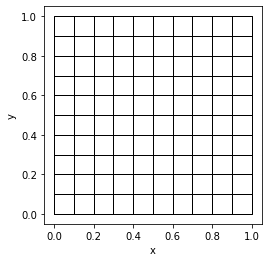

Number of elements = 100
Number of nodes = 121


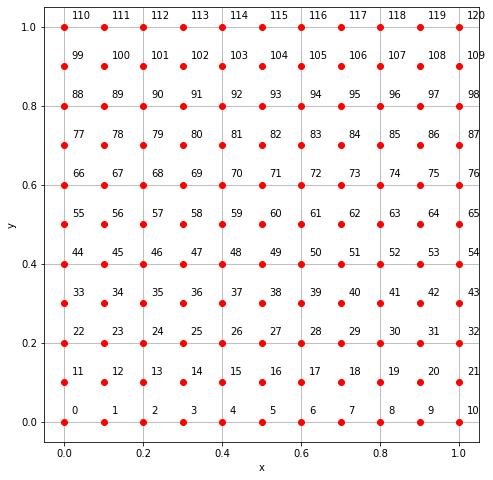

In [46]:
def draw_mesh(node_coordinates, element_nodes, element_type='Q4'):
    """
    Draw finite element mesh.
    """

    fig, ax = plt.subplots()

    if element_type.upper() == 'Q4':
        order = [0, 1, 2, 3, 0]

    elif element_type.upper() == 'T3':
        order = [0, 1, 2, 0]

    else:
        raise ValueError("Unsupported element type.")

    number_elements = element_nodes.shape[0]

    for e in range(number_elements):

        nodes = element_nodes[e]

        x = node_coordinates[nodes[order], 0]
        y = node_coordinates[nodes[order], 1]

        ax.plot(x, y, 'k-', linewidth=1)

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.show()




node_coordinates, element_nodes = rectangular_mesh(
    L, L,
    number_elements_x,
    number_elements_y
)

# Separate x and y coordinates
xx = node_coordinates[:, 0]
yy = node_coordinates[:, 1]

# Draw mesh
draw_mesh(node_coordinates, element_nodes, 'Q4')

# Total number of nodes
number_nodes = len(xx)

print("Number of elements =", number_elements)
print("Number of nodes =", number_nodes)

def get_mesh_numeration(xx, yy):
    """
    Plot mesh nodes and node numbering.
    """
    # Bigger figure
    fig, ax = plt.subplots(
        figsize=(10, 8)
    )
    # Plot nodes
    ax.plot(
        xx,
        yy,
        'ro',
        markersize=6
    )
    # Small offset for labels
    dx = 0.02 * (max(xx) - min(xx))
    dy = 0.02 * (max(yy) - min(yy))
    # Node numbering
    num_nodes = len(xx)
    for i in range(num_nodes):
        ax.text(
            xx[i] + dx,
            yy[i] + dy,
            f'{i}',
            fontsize=10
        )
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.show()
    return fig, ax
    
fig, ax = get_mesh_numeration(xx, yy)

# 7. Funções de forma do elemento Q4

O elemento quadrilateral de 4 nós (Q4) é definido no sistema de coordenadas naturais:

$$
-1 \le \xi \le 1
$$

$$
-1 \le \eta \le 1
$$

Cada ponto interno do elemento é interpolado pelas funções de forma:

$$
u(\xi,\eta)=\sum_{i=1}^{4} N_i(\xi,\eta) u_i
$$

onde $N_i$ são as funções de forma nodais.

---

## 7.1. Funções de forma

Para o elemento Q4:

$$
N_i=
\frac{1}{4}(1+\xi\xi_i)(1+\eta\eta_i)
$$

---

## 7.2. Vetor de interpolação

As funções de forma são agrupadas em:

$$
N=
\begin{bmatrix}
N_1 & N_2 & N_3 & N_4
\end{bmatrix}
$$

---

## 7.3. Derivadas naturais

As derivadas das funções de forma são:

$$
\frac{\partial N_i}{\partial \xi}
\quad,\quad
\frac{\partial N_i}{\partial \eta}
$$

Essas derivadas são usadas para construir:

- matriz Jacobiana;
- derivadas em coordenadas físicas;
- matrizes $B$ do elemento.

In [47]:
def get_shape_function(xi, eta, element_type='Q4'):
    """
    Shape functions and natural derivatives.
    
    Parameters
    ----------
    xi, eta : float
        Natural coordinates

    element_type : str
        Element type ('Q4', 'T3', ...)

    Returns
    -------
    shape : ndarray
        Shape functions
    natural_derivatives : ndarray
        [dN/dxi, dN/deta]
    """
    element_type = element_type.upper()

    # ============= Q4===========================
    if element_type == 'Q4':
        # Shape functions
        shape = 0.25 * np.array([
            (1 - xi) * (1 - eta),
            (1 + xi) * (1 - eta),
            (1 + xi) * (1 + eta),
            (1 - xi) * (1 + eta)
        ])
        # Natural derivatives
        natural_derivatives = 0.25 * np.array([
            [-(1 - eta), -(1 - xi)],
            [ (1 - eta), -(1 + xi)],
            [ (1 + eta),  (1 + xi)],
            [-(1 + eta),  (1 - xi)]
        ])

    # =========== T3 ===========================
    elif element_type == 'T3':
        shape = np.array([
            1 - xi - eta,
            xi,
            eta
        ])

        natural_derivatives = np.array([
            [-1.0, -1.0],
            [ 1.0,  0.0],
            [ 0.0,  1.0]
        ])
    else:
        raise ValueError("Unsupported element type.")
    return shape, natural_derivatives

N, dN = get_shape_function(0.0, 0.0, 'Q4')

print("Shape functions in (0,0) :")
print(N)

print("\nNatural derivatives:")
print(dN)

Shape functions in (0,0) :
[0.25 0.25 0.25 0.25]

Natural derivatives:
[[-0.25 -0.25]
 [ 0.25 -0.25]
 [ 0.25  0.25]
 [-0.25  0.25]]


# 8. Transformação geométrica e matriz Jacobiana

As funções de forma são inicialmente derivadas no sistema natural:

$$
(\xi,\eta)
$$

Para montar a rigidez do elemento, precisamos obter derivadas no sistema físico:

$$
(x,y)
$$

Essa transformação é feita pela matriz Jacobiana.

---

## 8.1. Matriz Jacobiana

A matriz Jacobiana é definida por:

$$
J=
\frac{\partial(x,y)}{\partial(\xi,\eta)}
$$

ou explicitamente:

$$
J=
\begin{bmatrix}
\frac{\partial x}{\partial \xi} &
\frac{\partial x}{\partial \eta}
\\
\frac{\partial y}{\partial \xi} &
\frac{\partial y}{\partial \eta}
\end{bmatrix}
$$

No código, ela é calculada por:

$$
J = X^T \frac{\partial N}{\partial (\xi,\eta)}
$$

onde:

- $X$ = coordenadas nodais do elemento;
- $N$ = funções de forma.

---

## 8.2. Inversa do Jacobiano

A transformação de coordenadas usa:

$$
J^{-1}
$$

---

## 8.3. Derivadas em coordenadas físicas

As derivadas espaciais são obtidas por:

$$
\frac{\partial N}{\partial(x,y)}
=
\frac{\partial N}{\partial(\xi,\eta)}
J^{-1}
$$

Essas derivadas são usadas para montar as matrizes:

$$
B_b
\quad,\quad
B_s
$$

do elemento de Mindlin.

In [48]:
def get_jacobian(node_coordinates, natural_derivatives):
    """
    Compute element Jacobian.

    Parameters
    ----------
    node_coordinates : ndarray
        Element nodal coordinates [n_nodes x 2]

    natural_derivatives : ndarray
        Shape function derivatives in natural coordinates
        [n_nodes x 2]

    Returns
    -------
    J : ndarray
        Jacobian matrix

    invJ : ndarray
        Inverse Jacobian

    derivatives : ndarray
        Shape function derivatives in physical coordinates
        [dN/dx, dN/dy]
    """

    # Jacobian matrix
    J = node_coordinates.T @ natural_derivatives

    # Inverse Jacobian
    invJ = np.linalg.inv(J)

    # Spatial derivatives
    derivatives = natural_derivatives @ invJ

    return J, invJ, derivatives

element = 0
indice = element_nodes[element]
coords = node_coordinates[indice]
N, dN_nat = get_shape_function(0.0, 0.0, 'Q4')
J, invJ, dN_xy = get_jacobian(coords, dN_nat)
print("Element nodes:")
print(indice)
print("\nJacobian:")
print(J)
print("\nDeterminante:")
print(np.linalg.det(J))
print("\nSpatial derivatives:")
print(dN_xy)

Element nodes:
[ 0  1 12 11]

Jacobian:
[[0.05 0.  ]
 [0.   0.05]]

Determinante:
0.0025000000000000005

Spatial derivatives:
[[-5. -5.]
 [ 5. -5.]
 [ 5.  5.]
 [-5.  5.]]


# 9. Integração numérica de Gauss

As integrais dos elementos finitos são calculadas numericamente usando quadratura de Gauss.

A integral no domínio natural do elemento é aproximada por:

$$
\int_{-1}^{1}\int_{-1}^{1}
f(\xi,\eta)
\, d\xi d\eta
\approx
\sum_{i=1}^{n_g}
w_i f(\xi_i,\eta_i)
$$

onde:

- $(\xi_i,\eta_i)$ são os pontos de integração;
- $w_i$ são os pesos de integração;
- $n_g$ é o número de pontos de Gauss.

---

## 9.1. Integração reduzida (1×1)

Usada na parte de cisalhamento para reduzir *shear locking*.

Ponto de integração:

$$
(\xi,\eta)=(0,0)
$$

Peso:

$$
w=4
$$

---

## 9.2. Integração completa (2×2)

Usada na parte de flexão.

Os pontos são:

$$
\xi,\eta=\pm \frac{1}{\sqrt{3}}
$$

ou aproximadamente:

$$
\xi,\eta=\pm0.577350269
$$

Total de pontos:

$$
n_g=4
$$

Cada ponto possui peso:

$$
w=1
$$

---

## 9.3. Integração refinada (3×3)

Pode ser usada quando se deseja maior precisão numérica.

Neste caso:

$$
\xi,\eta=
\{-0.774596669,\;0,\;+0.774596669\}
$$

Total de pontos:

$$
n_g=9
$$

In [94]:
def get_gauss_quadrature(order_type):
    """
    Gauss quadrature for quadrilateral elements.

    Options:
        'reduced'  -> 1x1
        'complete' -> 2x2
        '1x1'
        '2x2'
        '3x3'
    """
    order_type = order_type.lower()
    # ======== 1x1 quadrature =======================
    if order_type in ['1x1', 'reduced']:

        gauss_locations = np.array([
            [0.0, 0.0]
        ])

        gauss_weights = np.array([
            4.0
        ])

    # ======== 2x2 quadrature =======================
    elif order_type in ['2x2', 'complete']:
        a = 1.0 / np.sqrt(3.0)
        gauss_locations = np.array([
            [-a, -a],
            [ a, -a],
            [ a,  a],
            [-a,  a]
        ])
        gauss_weights = np.ones(4)
        
    # ======== 3x3 quadrature ========================
    elif order_type == '3x3':
        a = np.sqrt(3.0/5.0)
        gauss_locations = np.array([
            [-a, -a],
            [-a,  0.0],
            [-a,  a],

            [0.0, -a],
            [0.0,  0.0],
            [0.0,  a],

            [a, -a],
            [a,  0.0],
            [a,  a]
        ])

        w1 = 5.0/9.0
        w2 = 8.0/9.0

        gauss_weights = np.array([
            w1*w1,
            w1*w2,
            w1*w1,

            w2*w1,
            w2*w2,
            w2*w1,

            w1*w1,
            w1*w2,
            w1*w1
        ])
    else:
        raise ValueError("Unsupported quadrature type.")
    return gauss_weights, gauss_locations

In [95]:
# =====================================
# Test: Gauss integration on element 0
# =====================================
element = 0
# Connectivity of element 0
indice = element_nodes[element]
# Coordinates of element 0
coords = node_coordinates[indice]
print("Element 0 connectivity:")
print(indice)
print("\nElement 0 coordinates:")
print(coords)
# Get Gauss points (same used in bending)
weights, points = get_gauss_quadrature("complete")
print("\nGauss points:")
print(points)
print("\nGauss weights:")
print(weights)
# Loop over Gauss points
for q in range(len(weights)):
    xi = points[q, 0]
    eta = points[q, 1]
    # Shape functions
    N, dN_nat = get_shape_function(xi, eta, 'Q4')
    # Jacobian
    J, invJ, dN_xy = get_jacobian(coords, dN_nat)
    print(f"\n========================")
    print(f"Gauss point {q+1}")
    print(f"xi = {xi:.6f}, eta = {eta:.6f}")
    print("\nShape functions:")
    print(N)
    print("\nJacobian:")
    print(J)
    print("\nDet(J):")
    print(np.linalg.det(J))
    print("\nSpatial derivatives:")
    print(dN_xy)

Element 0 connectivity:
[ 0  1 12 11]

Element 0 coordinates:
[[0.  0. ]
 [0.1 0. ]
 [0.1 0.1]
 [0.  0.1]]

Gauss points:
[[-0.57735027 -0.57735027]
 [ 0.57735027 -0.57735027]
 [ 0.57735027  0.57735027]
 [-0.57735027  0.57735027]]

Gauss weights:
[1. 1. 1. 1.]

Gauss point 1
xi = -0.577350, eta = -0.577350

Shape functions:
[0.62200847 0.16666667 0.0446582  0.16666667]

Jacobian:
[[ 5.00000000e-02  2.39599633e-19]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -7.88675135]
 [ 7.88675135 -2.11324865]
 [ 2.11324865  2.11324865]
 [-2.11324865  7.88675135]]

Gauss point 2
xi = 0.577350, eta = -0.577350

Shape functions:
[0.16666667 0.62200847 0.16666667 0.0446582 ]

Jacobian:
[[ 5.00000000e-02  2.18901323e-18]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -2.11324865]
 [ 7.88675135 -7.88675135]
 [ 2.11324865  7.88675135]
 [-2.11324865  2.11324865]]

Gauss point 3
xi = 0.577350, 

In [96]:
# =====================================
# Test: Gauss integration on element 1
# =====================================
element = 1
# Connectivity of element 1
indice = element_nodes[element]
# Coordinates of element 1
coords = node_coordinates[indice]
print("Element 1 connectivity:")
print(indice)
print("\nElement 1 coordinates:")
print(coords)
# Get Gauss points (same used in bending)
weights, points = get_gauss_quadrature("complete")
print("\nGauss points:")
print(points)
print("\nGauss weights:")
print(weights)
# Loop over Gauss points
for q in range(len(weights)):
    xi = points[q, 0]
    eta = points[q, 1]
    # Shape functions
    N, dN_nat = get_shape_function(xi, eta, 'Q4')
    # Jacobian
    J, invJ, dN_xy = get_jacobian(coords, dN_nat)
    print(f"\n========================")
    print(f"Gauss point {q+1}")
    print(f"xi = {xi:.6f}, eta = {eta:.6f}")
    print("\nShape functions:")
    print(N)
    print("\nJacobian:")
    print(J)
    print("\nDet(J):")
    print(np.linalg.det(J))
    print("\nSpatial derivatives:")
    print(dN_xy)

Element 1 connectivity:
[ 1  2 13 12]

Element 1 coordinates:
[[0.1 0. ]
 [0.2 0. ]
 [0.2 0.1]
 [0.1 0.1]]

Gauss points:
[[-0.57735027 -0.57735027]
 [ 0.57735027 -0.57735027]
 [ 0.57735027  0.57735027]
 [-0.57735027  0.57735027]]

Gauss weights:
[1. 1. 1. 1.]

Gauss point 1
xi = -0.577350, eta = -0.577350

Shape functions:
[0.62200847 0.16666667 0.0446582  0.16666667]

Jacobian:
[[ 5.00000000e-02  2.18901323e-18]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0025000000000000005

Spatial derivatives:
[[-7.88675135 -7.88675135]
 [ 7.88675135 -2.11324865]
 [ 2.11324865  2.11324865]
 [-2.11324865  7.88675135]]

Gauss point 2
xi = 0.577350, eta = -0.577350

Shape functions:
[0.16666667 0.62200847 0.16666667 0.0446582 ]

Jacobian:
[[ 5.00000000e-02  2.39599633e-19]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -2.11324865]
 [ 7.88675135 -7.88675135]
 [ 2.11324865  7.88675135]
 [-2.11324865  2.11324865]]

Gauss point 3
xi = 0.577350, 

# 10. Montagem da matriz global de rigidez

$$
K = K_b + K_s
$$

A rigidez total do elemento é composta por duas contribuições:

- $K_b$: flexão da placa;
- $K_s$: cisalhamento transversal.

---

## 10.1. Rigidez de flexão

A contribuição de flexão é obtida por:

$$
K_b^{(e)}=
\int_{\Omega_e}
B_b^T
D_b
B_b
\, d\Omega
$$

onde:

- $B_b$ = matriz deformação-curvatura;
- $D_b$ = matriz constitutiva de flexão;
- $\Omega_e$ = domínio do elemento.

*A integração numérica é feita com quadratura completa de Gauss.

---

## 10.2. Rigidez de cisalhamento

A contribuição de cisalhamento é:

$$
K_s^{(e)}=
\int_{\Omega_e}
B_s^T
D_s
B_s
\, d\Omega
$$

onde:

- $B_s$ = matriz de deformação de cisalhamento;
- $D_s$ = matriz constitutiva de cisalhamento.

**A integração numérica é feita com quadratura reduzida.

Isso reduz o efeito de *shear locking*.

---

## 10.3. Transformação geométrica

As derivadas naturais $(\xi,\eta)$ são transformadas para coordenadas físicas $(x,y)$ usando o Jacobiano:

$$
J=
\frac{\partial(x,y)}{\partial(\xi,\eta)}
$$

---

## 10.4. Montagem global

Cada matriz de elemento é adicionada na matriz global através do mapeamento dos graus de liberdade:

$$
K^{global}
\leftarrow
K^{global}+K^{(e)}
$$

Cada nó possui 3 graus de liberdade:

$$
[w,\theta_x,\theta_y]
$$

portanto um elemento Q4 possui:

$$
4 \times 3 = 12
$$

graus de liberdade.

In [97]:
import numpy as np
def form_stiffness_matrix_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    C_shear,
    C_bending
):
    """
    Global stiffness matrix for Mindlin Q4 plate.
    """
    # Global stiffness matrix
    K = np.zeros((GDof, GDof))
    # ==========================================
    # BENDING CONTRIBUTION
    # ==========================================
    
    gauss_weights, gauss_locations = get_gauss_quadrature("complete")
    
    for e in range(number_elements):
        # element connectivity
        indice = element_nodes[e]
        # global DOF mapping
        element_dof = np.concatenate([
            indice,
            indice + number_nodes,
            indice + 2*number_nodes
        ])
        ndof = len(indice)
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q,0]
            eta = gauss_locations[q,1]
            # Shape functions
            shape, natural_derivatives = get_shape_function(xi, eta, "Q4")
            # Jacobian
            Jacob, invJacobian, XYderivatives = get_jacobian(node_coordinates[indice,:],natural_derivatives)
            # -------------------------
            # B matrix: bending
            # -------------------------
            B_b = np.zeros((3, 3*ndof))
            B_b[0, ndof:2*ndof] = XYderivatives[:,0]
            B_b[1, 2*ndof:3*ndof] = XYderivatives[:,1]
            B_b[2, ndof:2*ndof] = XYderivatives[:,1]
            B_b[2, 2*ndof:3*ndof] = XYderivatives[:,0]
            # element stiffness
            Ke = (
                B_b.T
                @ C_bending
                @ B_b
                * gauss_weights[q]
                * np.linalg.det(Jacob)
            )
            # Assembly
            K[np.ix_(element_dof, element_dof)] += Ke
            
    # ==========================================
    # SHEAR CONTRIBUTION
    # ==========================================
    gauss_weights, gauss_locations = get_gauss_quadrature("reduced")

    for e in range(number_elements):
        indice = element_nodes[e]
        element_dof = np.concatenate([
            indice,
            indice + number_nodes,
            indice + 2*number_nodes
        ])
        ndof = len(indice)
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q,0]
            eta = gauss_locations[q,1]
            shape, natural_derivatives = get_shape_function(xi, eta, "Q4")
            Jacob, invJacobian, XYderivatives = get_jacobian(node_coordinates[indice,:],natural_derivatives)
            # -------------------------
            # B matrix: shear
            # -------------------------
            B_s = np.zeros((2, 3*ndof))

            B_s[0, 0:ndof] = XYderivatives[:,0]
            B_s[1, 0:ndof] = XYderivatives[:,1]

            B_s[0, ndof:2*ndof] = shape
            B_s[1, 2*ndof:3*ndof] = shape

            # element stiffness
            Ke = (
                B_s.T
                @ C_shear
                @ B_s
                * gauss_weights[q]
                * np.linalg.det(Jacob)
            )

            # Assembly
            K[np.ix_(element_dof, element_dof)] += Ke

    return K

In [52]:
# =====================================
# Test: Global stiffness matrix
# =====================================

# Total degrees of freedom
# Each node has:
# w, theta_x, theta_y
GDof = 3 * number_nodes

# Build stiffness matrix
stiffness = form_stiffness_matrix_mindlin_q4(
    GDof=GDof,
    number_elements=number_elements,
    element_nodes=element_nodes,
    number_nodes=number_nodes,
    node_coordinates=node_coordinates,
    C_shear=D_shear,
    C_bending=D_bending
)

# =====================================
# Basic checks

print("Global matrix size:")
print(stiffness.shape)
print("\nNumber of DOFs:")
print(GDof)


# =====================================
# Symmetry check
symmetry_error = np.max(np.abs(stiffness - stiffness.T))
print("\nSymmetry error:")
print(symmetry_error)

# =====================================
# Element 0 DOFs
indice = element_nodes[0]
element_dof = np.concatenate([indice,indice + number_nodes,indice + 2*number_nodes])
print("\nElement 0 connectivity:")
print(indice)
print("\nElement 0 DOFs:")
print(element_dof)

# =====================================
# Diagonal terms
print("\nFirst 20 diagonal terms:")
print(np.round(np.diag(stiffness[:20, :20]), 4))

# =====================================
# Eigenvalue check
eigvals = np.linalg.eigvalsh(stiffness)
print("\nMinimum eigenvalue:")
print(np.min(eigvals))
print("\nMaximum eigenvalue:")
print(np.max(eigvals))

Global matrix size:
(363, 363)

Number of DOFs:
363

Symmetry error:
1.212789868532129e-14

Element 0 connectivity:
[ 0  1 12 11]

Element 0 DOFs:
[  0   1  12  11 121 122 133 132 242 243 254 253]

First 20 diagonal terms:
[180.621 361.242 361.242 361.242 361.242 361.242 361.242 361.242 361.242
 361.242 180.621 361.242 722.484 722.484 722.484 722.484 722.484 722.484
 722.484 722.484]

Minimum eigenvalue:
-9.746307585589851e-15

Maximum eigenvalue:
1387.5320974650535


# 11. Montagem do vetor global de forças

Nesta etapa calculamos o vetor global de carregamento externo da placa.

Consideramos uma carga distribuída transversal:

$$
P
$$

atuando ao longo da superfície do elemento.

---

## 11.1. Vetor de forças do elemento

A contribuição de cada elemento é:

$$
f^{(e)}=
\int_{\Omega_e}
N^T P
\, d\Omega
$$

onde:

- $N$ = funções de forma;
- $P$ = carga distribuída transversal;
- $\Omega_e$ = domínio do elemento.

---

## 11.2. Integração numérica

A integral é aproximada pela quadratura de Gauss:

$$
f^{(e)}
\approx
\sum_{i=1}^{n_g}
N^T(\xi_i,\eta_i)
P
\det(J)
w_i
$$

onde:

- $(\xi_i,\eta_i)$ = pontos de Gauss;
- $w_i$ = pesos;
- $\det(J)$ = determinante do Jacobiano.

---

## 11.3. Montagem global

Cada contribuição elementar é somada ao vetor global:

$$
F^{global}
\leftarrow
F^{global}+f^{(e)}
$$

A carga atua somente nos graus de liberdade de deslocamento:

$$
w
$$

não atuando diretamente nas rotações:

$$
\theta_x,\theta_y
$$

In [53]:
import numpy as np
def form_force_vector_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    P
):
    """
    Global force vector for Mindlin Q4 plate.

    Parameters
    ----------
    P : float
        Uniform transverse load
    """
    # Global force vector
    force = np.zeros(GDof)
    # Reduced integration
    gauss_weights, gauss_locations = get_gauss_quadrature("reduced")
    # Loop over elements
    for e in range(number_elements):
        # Element connectivity
        indice = element_nodes[e]
        # Loop over Gauss points
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q, 0]
            eta = gauss_locations[q, 1]
            weight = gauss_weights[q]
            # Shape functions
            shape, natural_derivatives = get_shape_function(
                xi, eta, 'Q4'
            )
            # Jacobian
            J, invJ, XYderivatives = get_jacobian(
                node_coordinates[indice, :],
                natural_derivatives
            )
            # Element force contribution
            fe = (
                shape
                * P
                * np.linalg.det(J)
                * weight
            )
            # Assembly only in transverse DOF (w)
            force[indice] += fe
    return force

In [54]:
# =====================================
# Test: Force vector
# =====================================
P = -1.0
F = form_force_vector_mindlin_q4(
    GDof=GDof,
    number_elements=number_elements,
    element_nodes=element_nodes,
    number_nodes=number_nodes,
    node_coordinates=node_coordinates,
    P=P
)
print("Force vector size:")
print(F.shape)
print("\nFirst 20 entries:")
print(np.round(F[:20], 6))
print("\nSum of forces:")
print(np.sum(F))

Force vector size:
(363,)

First 20 entries:
[-0.0025 -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005
 -0.005  -0.0025 -0.005  -0.01   -0.01   -0.01   -0.01   -0.01   -0.01
 -0.01   -0.01  ]

Sum of forces:
-0.9999999999999999


# 12. Condições de contorno essenciais

---

## Tipos de apoio

### 12.1. Simply Supported (SSSS)

Todos os lados simplesmente apoiados. Restrições:

$$
w=0
\quad \text{em todo o contorno}
$$

Além disso:

- bordas horizontais:

$$
\theta_x=0
$$

- bordas verticais:

$$
\theta_y=0
$$

---

### 12.2. Clamped (CCCC)

Todos os lados engastados. Restrições:

$$
w=0
$$

$$
\theta_x=0
$$

$$
\theta_y=0
$$

em todo o contorno.

---

### 12.3. Mixed Support (SCSC)

Condição mista.

Restrições dependem da direção das bordas.

---

### 12.4. Three Clamped, One Free (CCCF)

Três lados engastados e um lado livre. No lado livre não há restrição cinemática.

---

## 12.5. Separação dos graus de liberdade

Após aplicar as restrições, os graus de liberdade são separados em:

### Graus prescritos

$$
d_p
$$

### Graus ativos

$$
d_a
$$

Somente os graus ativos são resolvidos no sistema:

$$
K_{aa} u_a = F_a
$$

In [55]:
import numpy as np

def essential_bc(
    type_bc,
    GDof,
    xx,
    yy,
    node_coordinates,
    number_nodes
):
    """
    Essential boundary conditions for rectangular Mindlin plates.
    """
    xmin = np.min(node_coordinates[:, 0])
    xmax = np.max(node_coordinates[:, 0])

    ymin = np.min(node_coordinates[:, 1])
    ymax = np.max(node_coordinates[:, 1])

    tol = 1e-10

    # ==================================
    # SSSS
    # ==================================
    if type_bc.lower() == 'ssss':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = np.where(
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_ty = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol)
        )[0]

    # ==================================
    # CCCC
    # ==================================
    elif type_bc.lower() == 'cccc':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = fixed_node_w.copy()
        fixed_node_ty = fixed_node_w.copy()

    # ==================================
    # SCSC
    # ==================================
    elif type_bc.lower() == 'scsc':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol)
        )[0]

        fixed_node_ty = np.array([], dtype=int)

    # ==================================
    # CCCF
    # ==================================
    elif type_bc.lower() == 'cccf':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = fixed_node_w.copy()
        fixed_node_ty = fixed_node_w.copy()

    else:

        raise ValueError("Unsupported boundary condition.")

    # Global prescribed DOFs
    prescribed_dof = np.concatenate([
        fixed_node_w,
        fixed_node_tx + number_nodes,
        fixed_node_ty + 2*number_nodes
    ])
    prescribed_dof = np.unique(prescribed_dof)
    
    # Active DOFs
    all_dofs = np.arange(GDof)

    active_dof = np.setdiff1d(
        all_dofs,
        prescribed_dof
    )

    return prescribed_dof, active_dof, fixed_node_w

In [56]:
prescribed_dof, active_dof, fixed_nodes = essential_bc(
    type_bc='cccc',
    GDof=GDof,
    xx=xx,
    yy=yy,
    node_coordinates=node_coordinates,
    number_nodes=number_nodes
)

print("Fixed nodes (w):")
print(fixed_nodes)

print("\nNumber of prescribed DOFs:")
print(len(prescribed_dof))

print("\nNumber of active DOFs:")
print(len(active_dof))

print("\nFirst 20 active DOFs:")
print(active_dof[:20])

Fixed nodes (w):
[  0   1   2   3   4   5   6   7   8   9  10  11  21  22  32  33  43  44
  54  55  65  66  76  77  87  88  98  99 109 110 111 112 113 114 115 116
 117 118 119 120]

Number of prescribed DOFs:
120

Number of active DOFs:
243

First 20 active DOFs:
[12 13 14 15 16 17 18 19 20 23 24 25 26 27 28 29 30 31 34 35]


# 13. Montagem da matriz de massas

Inicialmente, cria-se uma matriz nula que irá armazenar todas as contribuições de massa dos elementos da malha:

$$
M = \mathbf{0}
$$

Para cada elemento e para cada ponto de integração $(\xi,\eta)$, são avaliadas:

- as funções de forma;
- suas derivadas;
- a transformação geométrica do elemento;
- as contribuições de massa translacional e rotacional.

---

## 13.1 Funções de forma do elemento

$$
shapeFunction =
\begin{bmatrix}
N_1 \\
N_2 \\
N_3 \\
N_4
\end{bmatrix}
$$

Cada função $N_i$ representa a influência do nó $i$ no ponto analisado do elemento.

---

## 13.2. Massa translacional

    A primeira contribuição adicionada à matriz global corresponde à inércia associada ao deslocamento transversal da placa. Fisicamente, essa parcela representa a resistência da estrutura à aceleração transversal. A contribuição elementar é calculada por:

$$
M^{(e)}_w
=
\int_{\Omega_e}
\rho \, h \, N^T N \, d\Omega
$$

onde:

- $N$ representa o vetor de funções de forma;
- $h$ é a espessura da placa;
- $\rho$ é a densidade do material;
- $w_q$ é o peso do ponto de Gauss.

---

## 13.3. Massa rotacional

    Além do deslocamento transversal, a teoria de Mindlin considera a inércia associada às rotações da seção transversal. Assim, também são adicionadas as contribuições referentes às rotações em torno dos eixos locais. A contribuição rotacional é dada por:
    
$$
M^{(e)}_\theta
=
\int_{\Omega_e}
\rho \, I \, N^T N \, d\Omega
$$

onde:

- $I$ representa a inércia rotacional da seção.

Essa contribuição é montada separadamente para os dois graus de liberdade rotacionais do elemento.

---

## 13.4. Montagem global

Após calcular as contribuições no ponto de Gauss, os termos elementares são adicionados à matriz global utilizando a conectividade nodal do elemento.

Esse procedimento é repetido para todos os elementos da malha, resultando na matriz de massa global completa da estrutura.

In [57]:
def formMassMatrixMindlinQ4(GDof,
                            number_elements,
                            element_nodes,
                            number_nodes,
                            node_coordinates,
                            thickness,
                            rho,
                            I):

    import numpy as np

    # mass matrix
    M = np.zeros((GDof, GDof))

    # Gauss quadrature
    gaussWeights, gaussLocations = \
        get_gauss_quadrature('complete')

    # cycle for element
    for e in range(number_elements):

        indice = element_nodes[e, :]
        ndof = len(indice)

        # cycle for Gauss point
        for q in range(len(gaussWeights)):

            GaussPoint = gaussLocations[q, :]

            xi = GaussPoint[0]
            eta = GaussPoint[1]

            # shape functions
            shapeFunction, naturalDerivatives = \
                get_shape_function(xi, eta, 'Q4')

            # Jacobian
            Jacob, invJacobian, XYderivatives = \
                get_jacobian(
                    node_coordinates[indice, :],
                    naturalDerivatives
                )

            # B matrix
            B_b = np.zeros((3, 3*ndof))

            B_b[0, ndof:2*ndof] = XYderivatives[:, 0]
            B_b[1, 2*ndof:3*ndof] = XYderivatives[:, 1]

            B_b[2, ndof:2*ndof] = XYderivatives[:, 1]
            B_b[2, 2*ndof:3*ndof] = XYderivatives[:, 0]

            # outer product
            NNT = np.outer(shapeFunction, shapeFunction)

            # translational contribution
            M[np.ix_(indice, indice)] += \
                NNT * thickness * rho * \
                gaussWeights[q] * np.linalg.det(Jacob)

            # rotational contribution theta_x
            M[np.ix_(indice + number_nodes,
                     indice + number_nodes)] += \
                NNT * I * rho * \
                gaussWeights[q] * np.linalg.det(Jacob)

            # rotational contribution theta_y
            M[np.ix_(indice + 2*number_nodes,
                     indice + 2*number_nodes)] += \
                NNT * I * rho * \
                gaussWeights[q] * np.linalg.det(Jacob)

    return M

In [58]:
# ============================================================
# MATRIZ DE MASSA DO PRIMEIRO ELEMENTO
# ============================================================

# primeiro elemento
e = 0
indice = element_nodes[e, :].astype(int)
mass = formMassMatrixMindlinQ4(GDof,number_elements,element_nodes,number_nodes,node_coordinates,thickness,rho,I)

# graus de liberdade do elemento
element_dofs = np.concatenate([indice,indice + number_nodes,indice + 2*number_nodes])

# extrai somente a matriz do elemento
mass_element = mass[np.ix_(element_dofs, element_dofs)]

print('Matriz de massa do elemento 0:\n')
print(mass_element)
print('\nShape da matriz do elemento:')
print(mass_element.shape)

Matriz de massa do elemento 0:

[[1.11111111e-04 5.55555556e-05 2.77777778e-05 5.55555556e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.55555556e-05 2.22222222e-04 1.11111111e-04 2.77777778e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.77777778e-05 1.11111111e-04 4.44444444e-04 1.11111111e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.55555556e-05 2.77777778e-05 1.11111111e-04 2.22222222e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  9.25925926e-08 4.62962963e-08 2.31481481e-08 4.62962963e-08
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0

# 14. Matriz de amortecimento de Rayleigh

$$
C
=
\alpha M
+
\beta K
$$

onde:

- $M$ é a matriz global de massa;
- $K$ é a matriz global de rigidez;
- $\alpha$ é o coeficiente de amortecimento proporcional à massa;
- $\beta$ é o coeficiente de amortecimento proporcional à rigidez.

---

A parcela:

$$
\alpha M
$$

atua principalmente nos modos de baixa frequência, enquanto:

$$
\beta K
$$

atua predominantemente nos modos de alta frequência.

---

In [59]:
# ============================================================
# MATRIZ DE AMORTECIMENTO DE RAYLEIGH

def formDumpMatrixMindlinQ4(alpha,
                            beta,
                            mass,
                            stiffness):
    # coeficiente proporcional à massa
    alpha = 0.1
    # coeficiente proporcional à rigidez
    beta = 0.01
    # matriz de amortecimento
    C = alpha * mass + beta * stiffness
    return C

In [88]:
# ------------------------------------------------------------
# TESTE MATRIZ DE AMORTECIMENTO
alpha = 0.1
beta = 0.01
dump = formDumpMatrixMindlinQ4(alpha,beta,mass,stiffness)

print('\nShape da matriz C:')
print(dump.shape)


Shape da matriz C:
(363, 363)


# 15. Solução do sistema dinâmico

## 15.1 Equação geral do sistema dinâmico

Após a montagem das matrizes globais:

- matriz de massa $M$;
- matriz de amortecimento $C$;
- matriz de rigidez $K$;

e após a aplicação das condições de contorno, o problema dinâmico da placa é escrito como:

$$
M\ddot{u}
+
C\dot{u}
+
Ku
=
F(t)
$$

onde:

- $u$ representa os deslocamentos nodais;
- $F(t)$ é o carregamento externo dependente do tempo.

---

## 15.2. Sistema reduzido

As condições de contorno removem os graus de liberdade prescritos do sistema global.

Assim, o sistema resolvido numericamente envolve apenas os graus de liberdade ativos:

$$
M_{aa}\ddot{u}_a
+
C_{aa}\dot{u}_a
+
K_{aa}u_a
=
F_a
$$

onde:

- $M_{aa}$ é a matriz de massa reduzida;
- $C_{aa}$ é a matriz de amortecimento reduzida;
- $K_{aa}$ é a matriz de rigidez reduzida;
- $u_a$ contém os deslocamentos desconhecidos;
- $F_a$ contém as forças aplicadas nos graus livres.


---



In [87]:
# matrizes reduzidas (graus de liberdade ativos)
def reduceMatrixMindlinQ4(stiffness,
                          mass,
                          dump):
    K = stiffness[np.ix_(active_dof, active_dof)]
    M = mass[np.ix_(active_dof, active_dof)]
    C = dump[np.ix_(active_dof, active_dof)]

    return K,M,C


In [62]:
# ============================================================
# VERIFICAÇÃO
# ============================================================

(K,M,C) = reduceMatrixMindlinQ4(stiffness,mass,dump)
ndof = len(active_dof)
print('Shape de K:', K.shape)
print('Shape de M:', M.shape)
print('Shape de C:', C.shape)
print('\nNúmero de graus de liberdade ativos:')
print(active_dof)

Shape de K: (243, 243)
Shape de M: (243, 243)
Shape de C: (243, 243)

Número de graus de liberdade ativos:
[ 12  13  14  15  16  17  18  19  20  23  24  25  26  27  28  29  30  31
  34  35  36  37  38  39  40  41  42  45  46  47  48  49  50  51  52  53
  56  57  58  59  60  61  62  63  64  67  68  69  70  71  72  73  74  75
  78  79  80  81  82  83  84  85  86  89  90  91  92  93  94  95  96  97
 100 101 102 103 104 105 106 107 108 133 134 135 136 137 138 139 140 141
 144 145 146 147 148 149 150 151 152 155 156 157 158 159 160 161 162 163
 166 167 168 169 170 171 172 173 174 177 178 179 180 181 182 183 184 185
 188 189 190 191 192 193 194 195 196 199 200 201 202 203 204 205 206 207
 210 211 212 213 214 215 216 217 218 221 222 223 224 225 226 227 228 229
 254 255 256 257 258 259 260 261 262 265 266 267 268 269 270 271 272 273
 276 277 278 279 280 281 282 283 284 287 288 289 290 291 292 293 294 295
 298 299 300 301 302 303 304 305 306 309 310 311 312 313 314 315 316 317
 320 321 322 323 

## 16. Análise Modal

Nesta etapa, resolve-se o problema generalizado de autovalores da estrutura discretizada por elementos finitos. O objetivo é obter:

- **$V$**: modos de vibrar (autovetores)
- **$D$**: autovalores adimensionais
- **$f_n$**: frequências naturais da estrutura

O problema modal é definido por:

$$
K \phi = \lambda M \phi
$$

onde:

- $K$ = matriz de rigidez global  
- $M$ = matriz de massa global  
- $\lambda$ = autovalores  
- $\phi$ = autovetores ou modos de vibrar  

---

### 16.1. Resolução Numérica

O problema de autovalores generalizado é resolvido numericamente utilizando o método iterativo `eigsh()`, que calcula os modos de cada frequência da estrutura:

$$
K \phi_i = \lambda_i M \phi_i
$$

---

### 16.2. Frequências Adimensionais

Após resolver o problema de autovalores, calcula-se a frequência adimensional de cada modo:

$$
D_i = \sqrt{\lambda_i} \, L \sqrt{\frac{\rho}{G}}
$$

onde:

- $L$ = comprimento característico da placa  
- $\rho$ = densidade do material  
- $G$ = módulo de cisalhamento  

Essa forma adimensional permite comparar resultados entre diferentes geometrias e materiais.

---

### 16.3. Ordenação Modal

Os autovalores são ordenados em ordem crescente:

$$
D_1 < D_2 < D_3 < \cdots < D_n
$$

e os autovetores são reorganizados na mesma sequência para manter a consistência modal.

---

### 16.4. Frequências Naturais

As frequências naturais em Hertz são calculadas por:

$$
a_{dim} = L \sqrt{\frac{\rho}{G}}
$$

e:

$$
f_n = \frac{D}{a_{dim} \, 2\pi}
$$

Substituindo $D$ na equação anterior:

$$
f_n = \frac{\sqrt{\lambda}}{2\pi}
$$

obtendo-se a frequência natural física de cada modo de vibração.

---

### Saídas da Função

A função retorna:

- $V$ → matriz dos modos de vibrar  
- $D$ → frequências adimensionais  
- $f_n$ → frequências naturais em Hz  

Esses resultados serão utilizados posteriormente na projeção modal e na integração temporal pelo método de Newmark.

In [89]:
import numpy as np
from scipy.sparse.linalg import eigsh


def ModalAnalysis(K, M, L, rho, G, numberOfModes):

    # =====================================
    # Modal analysis
    # =====================================
    # V : mode shape
    # D : frequency

    # eigs(K,M,...)
    # Python retorna primeiro autovalores e depois autovetores
    D, V = eigsh(
        K,
        k=numberOfModes,
        M=M,
        which='SM'   # smallestabs
    )

    # [D,ii]=sort(D)
    ii = np.argsort(D)
    D = D[ii]

    # D = diag(sqrt(D)*L*sqrt(rho/G))
    D = np.sqrt(np.abs(D)) * L * np.sqrt(rho / G)

    # V = V(:,ii)
    V = V[:, ii]

    # Natural frequencies
    adim = L * np.sqrt(rho / G)
    fn = (D / adim) / (2*np.pi)

    return V, D, fn

In [98]:
numberOfModes = len(active_dof)
#numberOfModes = 12

V, D, fn = ModalAnalysis(
    K,
    M,
    L,
    rho,
    G,
    numberOfModes
)

# Print frequencies
for i in range(numberOfModes):
    print(f"fn{i+1} = {fn[i]:.6f} Hz")

fn1 = 16.769874 Hz
fn2 = 33.035127 Hz
fn3 = 33.035127 Hz
fn4 = 46.090753 Hz
fn5 = 57.370434 Hz
fn6 = 57.955250 Hz
fn7 = 67.640142 Hz
fn8 = 67.640142 Hz
fn9 = 85.066633 Hz
fn10 = 89.596509 Hz
fn11 = 89.596509 Hz
fn12 = 96.339141 Hz
fn13 = 97.470277 Hz
fn14 = 109.988568 Hz
fn15 = 109.988568 Hz
fn16 = 119.501541 Hz
fn17 = 128.227096 Hz
fn18 = 128.550239 Hz
fn19 = 129.506050 Hz
fn20 = 133.297400 Hz
fn21 = 133.297400 Hz
fn22 = 141.482266 Hz
fn23 = 142.813668 Hz
fn24 = 155.637323 Hz
fn25 = 155.637323 Hz
fn26 = 173.577264 Hz
fn27 = 173.577264 Hz
fn28 = 174.031132 Hz
fn29 = 174.031132 Hz
fn30 = 174.311135 Hz
fn31 = 175.798391 Hz
fn32 = 176.496719 Hz
fn33 = 180.859860 Hz
fn34 = 180.859860 Hz
fn35 = 187.523553 Hz
fn36 = 188.621964 Hz
fn37 = 198.110093 Hz
fn38 = 198.110093 Hz
fn39 = 198.868562 Hz
fn40 = 211.062420 Hz
fn41 = 220.538842 Hz
fn42 = 220.551492 Hz
fn43 = 223.143247 Hz
fn44 = 223.143247 Hz
fn45 = 223.425723 Hz
fn46 = 223.560282 Hz
fn47 = 223.826383 Hz
fn48 = 223.826383 Hz
fn49 = 224.088

# 17. Critério de estabilidade temporal

A integração temporal é realizada pelo método explícito das diferenças centrais.

Para garantir estabilidade numérica, o passo de tempo deve satisfazer:

$$
\Delta t
<
\Delta t_{crit}
$$

sendo:

$$
\Delta t_{crit}
=
\frac{2}{\omega_{max}}
$$

onde:

$$
\omega_{max}
=
2\pi f_{max}
$$

representa a maior frequência natural do sistema.


In [81]:
# ============================================================
# CONVERGÊNCIA TEMPORAL
# ============================================================
dt = 1
# frequência natural máxima (Hz)
fn_max = fn[-1]
wn_max = 2*np.pi*fn_max
# passo de tempo crítico
dt_max = 2/wn_max

# verificação de estabilidade
if dt > dt_max:
    # dt = dt_max
    dt = (10**np.floor(np.log10(dt_max)))

# ============================================================
# DISCRETIZAÇÃO TEMPORAL
# ============================================================
tmax = 2
time = np.arange(0, tmax + dt, dt)
nt = len(time)

print('Passo de tempo crítico:')
print(dt_max)

print('\nPasso de tempo utilizado:')
print(dt)

print('\nNúmero de passos no tempo:')
print(nt)

Passo de tempo crítico:
0.0004694089365787089

Passo de tempo utilizado:
0.0001

Número de passos no tempo:
20001


## 18. Normalização Modal em Relação à Massa

Após a solução do problema de autovalores, os modos de vibrar obtidos numericamente nem sempre estão perfeitamente ortogonais, principalmente em estruturas com simetria geométrica, como placas quadradas de :contentReference[oaicite:0]{index=0}.

Nesses casos, podem aparecer **modos degenerados**, ou seja, modos com frequências muito próximas ou idênticas. Isso pode gerar perda de ortogonalidade numérica.

Para corrigir isso, aplica-se uma etapa de:

1. **Ortogonalização de Gram-Schmidt**
2. **Normalização em relação à massa**

---

## 18.1. Ortogonalização de Gram-Schmidt

Cada modo $V_i$ é tornado ortogonal em relação aos modos anteriores.

A projeção modal é calculada por:

$$
p_{ij} = V_j^T M V_i
$$

onde:

- $V_i$ = modo atual
- $V_j$ = modo já ortogonalizado
- $M$ = matriz de massa global

Essa projeção mede quanto do modo $V_i$ está "contaminado" pelo modo anterior $V_j$.

Em seguida, remove-se essa componente:

$$
V_i = V_i - p_{ij}V_j
$$

Após esse processo, os modos tornam-se ortogonais em relação à matriz de massa.

---

## 18.2. Normalização em Massa

Depois da ortogonalização, cada modo é normalizado para que sua massa modal seja unitária.

A massa modal é dada por:

$$
m_i = V_i^T M V_i
$$

Em seguida, o modo é normalizado:

$$
V_i = \frac{V_i}{\sqrt{m_i}}
$$

Após essa etapa:

$$
V_i^T M V_i = 1
$$

ou seja, cada modo possui massa modal unitária.

---

## 18.3. Condição Final de Ortogonalidade

Após o processo completo, os modos devem satisfazer:

$$
V_i^T M V_j =
\begin{cases}
1, & i=j \\
0, & i\neq j
\end{cases}
$$

ou de forma matricial:

$$
V^T M V = I
$$

onde $I$ é a matriz identidade.

---

## 18.4. Verificação Numérica

A matriz modal de massa é então calculada por:

$$
M_{modal} = V^T M V
$$

Idealmente, o resultado deve ser próximo de:

$$
M_{modal} \approx
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

Isso confirma que os modos estão corretamente ortogonais e normalizados.

---

## Importância Física

Essa etapa é fundamental para a superposição modal, pois garante que o sistema dinâmico desacople em equações independentes:

$$
m_i\ddot{Q}_i + c_i\dot{Q}_i + k_iQ_i = f_i(t)
$$

permitindo integrar cada modo separadamente no domínio do tempo usando o método de Newmark.

In [92]:
# =====================================
# Robust normalization (Gram-Schmidt + Mass Norm)
# Forces orthogonality even for repeated modes
# =====================================

for i in range(numberOfModes):

    # Gram-Schmidt orthogonalization
    for j in range(i):

        # projection = V(:,j)' * M * V(:,i)
        projection = V[:, j].T @ M @ V[:, i]

        # V(:,i) = V(:,i) - projection * V(:,j)
        V[:, i] = V[:, i] - projection * V[:, j]

    # Mass normalization
    modal_mass = V[:, i].T @ M @ V[:, i]

    # V(:,i) = V(:,i) / sqrt(V(:,i)' * M * V(:,i))
    V[:, i] = V[:, i] / np.sqrt(modal_mass)

Mmodal = V.T @ M @ V
print(np.round(Mmodal, 6))

[[ 1.  0. -0. ... -0. -0.  0.]
 [ 0.  1.  0. ... -0. -0.  0.]
 [-0. -0.  1. ...  0.  0. -0.]
 ...
 [-0. -0.  0. ...  1.  0.  0.]
 [ 0.  0.  0. ... -0.  1.  0.]
 [ 0.  0. -0. ...  0.  0.  1.]]


## 19. Projeção Modal do Sistema Dinâmico

Após obter e normalizar os modos de vibrar, o próximo passo consiste em projetar o sistema físico para o espaço modal.

A equação dinâmica original da estrutura é dada por:

$$
M\ddot{u} + C\dot{u} + Ku = F(t)
$$

onde:

- $M$ = matriz de massa global  
- $C$ = matriz de amortecimento global  
- $K$ = matriz de rigidez global  
- $u$ = vetor de deslocamentos físicos  
- $F(t)$ = vetor de forças externas  

---

## 19.1. Transformação Modal

Assume-se que a resposta estrutural pode ser escrita como uma combinação linear dos modos de vibrar:

$$
u(t) = VQ(t)
$$

onde:

- $V$ = matriz modal (modos de vibrar)
- $Q(t)$ = coordenadas modais

Substituindo na equação dinâmica:

$$
M V \ddot{Q} + C V \dot{Q} + K V Q = F(t)
$$

Multiplicando ambos os lados por $V^T$:

$$
V^T M V \ddot{Q}
+
V^T C V \dot{Q}
+
V^T K V Q
=
V^T F(t)
$$

---

## 19.2. Matrizes Modais

As matrizes projetadas são calculadas como:

### Massa Modal

$$
M_{mod} = V^T M V
$$

Como os modos foram normalizados em relação à massa, idealmente:

$$
M_{mod} \approx I
$$

onde $I$ é a matriz identidade.

---

### Rigidez Modal

$$
K_{mod} = V^T K V
$$

Essa matriz contém as rigidezes associadas a cada modo de vibração.

---

### Amortecimento Modal

$$
C_{mod} = V^T C V
$$

Essa matriz representa o amortecimento projetado no espaço modal.

---

## 19.3. Desacoplamento do Sistema

Após a projeção, o sistema global acoplado transforma-se em um conjunto de equações independentes:

$$
m_i \ddot{Q}_i
+
c_i \dot{Q}_i
+
k_i Q_i
=
f_i(t)
$$

Cada modo passa a se comportar como um sistema de um grau de liberdade (SDOF), permitindo integrar cada equação separadamente.

---

## 19.4. Inicialização das Coordenadas Modais

Para integrar no tempo, são definidos três vetores:

### Deslocamento modal

$$
Q
$$

### Velocidade modal

$$
\dot{Q}
$$

### Aceleração modal

$$
\ddot{Q}
$$

Todos são inicializados com zero no instante inicial:

$$
Q(0)=\dot{Q}(0)=\ddot{Q}(0)=0
$$

Essas variáveis serão utilizadas posteriormente na integração temporal pelo método de Newmark.

In [73]:
# =====================================
# Matrix projection
# =====================================

Mmod = V.T @ M @ V
Kmod = V.T @ K @ V
Cmod = V.T @ C @ V

print(Mmod[:5, :5])
print(Kmod[:5, :5])


Q  = np.zeros((numberOfModes, nt))
Qd = np.zeros((numberOfModes, nt))
Qa = np.zeros((numberOfModes, nt))

[[ 1.00000000e+00  8.22585107e-17 -1.07077138e-16  3.39882420e-17
   3.22055202e-19]
 [ 3.52142350e-17  1.00000000e+00  5.53719036e-17 -1.65953564e-16
  -2.06223415e-17]
 [-4.25403414e-17 -1.70684754e-17  1.00000000e+00  8.44345331e-17
   2.07129131e-17]
 [-1.38210784e-17 -3.91310392e-18  6.69638538e-17  1.00000000e+00
  -1.87513534e-17]
 [ 2.68427056e-17  5.70907821e-17  3.36765400e-17 -2.88873848e-17
   1.00000000e+00]]
[[ 1.11024636e+04 -3.75421371e-10  7.38641086e-10  8.33288002e-10
   7.02405627e-12]
 [-3.68499996e-10  4.30835721e+04  1.38444079e-11 -1.92857822e-10
  -1.88097045e-10]
 [ 7.28891745e-10  1.57999131e-11  4.30835721e+04 -6.39817553e-10
   2.65433748e-10]
 [ 8.31234258e-10 -1.95781513e-10 -6.36804442e-10  8.38662728e+04
  -1.71399604e-10]
 [ 5.58118477e-12 -1.69954244e-10  2.86569321e-10 -1.62020017e-10
   1.29937947e+05]]


# 20. Método de Newmark

## 21.1 Abordagem geral
O método de Newmark integra numericamente a equação dinâmica:

$$
M\ddot{u}
+
C\dot{u}
+
Ku
=
F(t)
$$

assumindo uma variação aproximada de velocidades e acelerações dentro de cada incremento de tempo.

As velocidades são atualizadas por:

$$
\dot{u}_{n+1}
=
\dot{u}_n
+
\Delta t
\left[
(1-\gamma)\ddot{u}_n
+
\gamma\ddot{u}_{n+1}
\right]
$$

As acelerações são relacionadas aos deslocamentos por:

$$
\ddot{u}_{n+1}
=
\frac{u_{n+1}-u_n}{\beta \Delta t^2}
-
\frac{\dot{u}_n}{\beta \Delta t}
-
\left(
\frac{1}{2\beta}
-
1
\right)
\ddot{u}_n
$$

Para este trabalho foram adotados os parâmetros:

$$
\gamma=\frac{1}{2}
\qquad
\beta=\frac{1}{4}
$$

correspondentes ao método da aceleração média constante, que é
**incondicionalmente estável para sistemas lineares**.

---

## 22.2. Rigidez efetiva

Substituindo as expressões anteriores na equação dinâmica, obtém-se o sistema linear:

$$
K_{eff}u_{n+1}
=
F_{eff}
$$

onde:

$$
K_{eff}
=
K
+
\frac{\gamma}{\beta\Delta t}C
+
\frac{1}{\beta\Delta t^2}M
$$

e a força efetiva é dada por:

$$
F_{eff}
=
F_n
+
M
\left[
\frac{u_n}{\beta\Delta t^2}
+
\frac{\dot{u}_n}{\beta\Delta t}
+
\left(
\frac{1}{2\beta}
-
1
\right)
\ddot{u}_n
\right]
+
C
\left[
\frac{\gamma}{\beta\Delta t}u_n
+
\left(
\frac{\gamma}{\beta}
-
1
\right)\dot{u}_n
+
\Delta t
\left(
\frac{\gamma}{2\beta}
-
1
\right)
\ddot{u}_n
\right]
$$

Assim, os deslocamentos são obtidos por:

$$
u_{n+1}
=
K_{eff}^{-1}
F_{eff}
$$

Após isso, atualizam-se acelerações e velocidades.

---

## 22.3. Condições iniciais

A aceleração inicial é obtida diretamente da equação dinâmica:

$$
\ddot{u}_0
=
M^{-1}
\left(
F_0
-
C\dot{u}_0
-
Ku_0
\right)
$$

onde:

- $u_0$ = deslocamento inicial;
- $\dot{u}_0$ = velocidade inicial;
- $\ddot{u}_0$ = aceleração inicial.

---

## 22.4. Carregamento harmônico

O carregamento aplicado no nó central da placa é definido como:

$$
F(t)
=
F_0\sin(\omega t)
$$

com:

$$
\omega
=
2\pi f
$$

onde:

- $F_0$ é a amplitude da força;
- $f$ é a frequência de excitação;
- $\omega$ é a frequência angular.

A força é aplicada no grau de liberdade correspondente ao nó excitado.

---

## 22.5. Integração Temporal na Base Modal

Na formulação física, a equação dinâmica da estrutura é dada por:

$$
M\ddot{u} + C\dot{u} + Ku = F(t)
$$

onde:

- $M$ = matriz de massa  
- $C$ = matriz de amortecimento  
- $K$ = matriz de rigidez  
- $x(t)$ = deslocamentos físicos da estrutura  
- $F(t)$ = carregamento externo  

---

## Transformação para o Espaço Modal

Assume-se que a resposta estrutural pode ser escrita como:

$$
u(t) = VQ(t)
$$

onde:

- $V$ = matriz dos modos de vibrar  
- $Q(t)$ = coordenadas modais  

Substituindo na equação dinâmica e projetando no espaço modal, obtém-se:

$$
V^T M V \ddot{Q}
+
V^T C V \dot{Q}
+
V^T K V Q
=
V^T F(t)
$$

ou de forma simplificada:

$$
M_{mod}\ddot{Q}
+
C_{mod}\dot{Q}
+
K_{mod}Q
=
F_{mod}(t)
$$

---

## Equações Desacopladas

Como as matrizes modais tornam-se aproximadamente diagonais, cada modo passa a ser resolvido independentemente.

Para cada modo $i$:

$$
m_i\ddot{Q}_i
+
c_i\dot{Q}_i
+
k_iQ_i
=
f_i(t)
$$

onde:

- $m_i$ = massa modal  
- $c_i$ = amortecimento modal  
- $k_i$ = rigidez modal  
- $f_i(t)$ = força modal  

---

## Método de Newmark na Base Modal

As equações de integração temporal do método de Newmark permanecem exatamente as mesmas da formulação física.

A única diferença é a troca das variáveis físicas pelas coordenadas modais:

$$
u \rightarrow Q
$$

$$
\dot{u} \rightarrow \dot{Q}
$$

$$
\ddot{u} \rightarrow \ddot{Q}
$$

Assim, cada modo é integrado como um sistema de um grau de liberdade (SDOF), utilizando:

$$
m_i,\; c_i,\; k_i,\; f_i(t)
$$

Esse procedimento reduz significativamente o custo computacional, pois transforma um sistema global acoplado em vários sistemas independentes.

In [93]:
import numpy as np

def NewmarkModeSuperposition(
    V,
    Mmod,
    Cmod,
    Kmod,
    active_dof,
    forceDof,
    F0,
    omega,
    time,
    dt,
    numberOfModes
):

    # =====================================
    # Newmark modal superposition
    # =====================================

    gamma = 1/2
    betaN = 1/4
    nt = len(time)

    # Physical force vector
    Fphys = np.zeros(len(active_dof))

    for n in range(nt - 1):

        # Force at current time step
        Fphys[:] = 0.0
        Fphys[force_dof] = F0 * np.sin(omega * time[n])

        # Modal force projection
        Fmod = V.T @ Fphys

        # Integrate mode by mode
        for i in range(numberOfModes):

            m = Mmod[i, i]
            c = Cmod[i, i]
            k = Kmod[i, i]

            Keff = (
                k
                + gamma/(betaN*dt)*c
                + m/(betaN*dt**2)
            )

            f = Fmod[i]

            feff = (
                f
                + m*(
                    Q[i, n]/(betaN*dt**2)
                    + Qd[i, n]/(betaN*dt)
                    + (1/(2*betaN)-1)*Qa[i, n]
                )
                + c*(
                    gamma/(betaN*dt)*Q[i, n]
                    + (gamma/betaN-1)*Qd[i, n]
                    + dt*(gamma/(2*betaN)-1)*Qa[i, n]
                )
            )

            # Displacement
            Q[i, n+1] = feff / Keff

            # Acceleration
            Qa[i, n+1] = (
                (Q[i, n+1] - Q[i, n])/(betaN*dt**2)
                - Qd[i, n]/(betaN*dt)
                - (1/(2*betaN)-1)*Qa[i, n]
            )

            # Velocity
            Qd[i, n+1] = (
                Qd[i, n]
                + dt*((1-gamma)*Qa[i, n] + gamma*Qa[i, n+1])
            )

    return Q, Qd, Qa

# 23. Reconstrução do vetor global

Após resolver o sistema reduzido, os deslocamentos calculados são inseridos novamente no vetor global.

O vetor global final possui a forma:

$$
u=
\begin{bmatrix}
u_p \\
u_a
\end{bmatrix}
$$

onde:

- $u_p$ representa os graus de liberdade prescritos;
- $u_a$ representa os deslocamentos obtidos numericamente.

Dessa forma, obtém-se o campo completo de deslocamentos da estrutura ao longo do tempo.

Nó central:
60

Grau de liberdade global:
60

Posição no sistema reduzido:
40


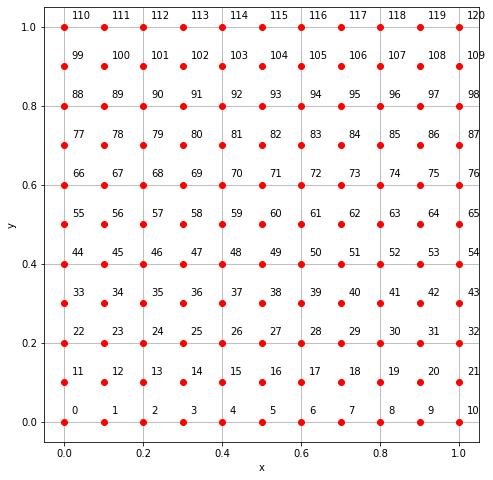


First 20 displacement values:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.02128378e-05 2.00255484e-05 6.58664557e-05 6.16855135e-05
 9.76620994e-05 6.16855135e-05 6.58664557e-05 2.00255484e-05]

Maximum displacement:
0.008174631158090952

Minimum displacement:
-0.008174631158090952

Transverse displacements at final time step:
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.02128378e-05 2.00255484e-05 6.58664557e-05 6.16855135e-05
 9.76620994e-05 6.16855135e-05 6.58664557e-05 2.00255484e-05
 1.02128378e-05 0.00000000e+00 0.00000000e+00 2.00255484e-05
 1.10571552e-04 1.48798808e-04 2.63460401e-04 2.26995402e-04
 2.63460401e-04 1.48798808e-04 1.10571552e-04 2.00255484e-05
 0.00000000e+00 0.00000000e+00 6.5866455

In [86]:
import math
import numpy as np

# =====================================
# Dynamic solution test
# =====================================

# Stiffness matrix
stiffness = form_stiffness_matrix_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    D_shear,
    D_bending
)

# Mass matrix
mass = formMassMatrixMindlinQ4(GDof,
                            number_elements,
                            element_nodes,
                            number_nodes,
                            node_coordinates,
                            thickness,
                            rho,
                            I)

# Dump matrix
alpha = 0.1
beta = 0.01
dump = formDumpMatrixMindlinQ4(alpha,
                               beta,
                               mass,
                               stiffness)

# Boundary conditions
prescribed_dof, active_dof, fixed_nodes = essential_bc(
    'cccc',
    GDof,
    xx,
    yy,
    node_coordinates,
    number_nodes
)

# Reduced matrix
(K,M,C) = reduceMatrixMindlinQ4(stiffness,
                                mass,
                                dump)

# Load vector
centralNode = int(np.ceil(number_nodes / 2)) - 1
forceDofGlobal = centralNode
# posição dentro dos graus ativos
force_dof = np.where(active_dof == forceDofGlobal)[0][0]
F0 = -1
freq=2
omega = 2 * np.pi * freq

print('Nó central:')
print(centralNode)
print('\nGrau de liberdade global:')
print(forceDofGlobal)
print('\nPosição no sistema reduzido:')
print(force_dof)

fig, ax = get_mesh_numeration(xx, yy)

# Newmark mode Superposition
Q, Qd, Qa = NewmarkModeSuperposition(
    V,
    Mmod,
    Cmod,
    Kmod,
    active_dof,
    force_dof,
    F0,
    omega,
    time,
    dt,
    numberOfModes
)

# RECONSTRUÇÃO DO VETOR GLOBAL
Uglobal = np.zeros((GDof, nt))
U = V @ Q
for n in range(nt):
    Uglobal[active_dof, n] = U[:, n]
    
# ============================================================
# GRAUS DE LIBERDADE TRANSVERSAIS
# ordem global:
# [ w1 ... wn | theta_x | theta_y ]

wDof = np.arange(number_nodes)

# Extract transverse displacement only
w = Uglobal[wDof, :]
print("\nFirst 20 displacement values:")
print(w[:20, -1])

# ============================================================
# DESLOCAMENTO MÁXIMO
wmax = np.max(np.abs(w))
print("\nMaximum displacement:")
print(wmax)

wmin = np.min(w)
print("\nMinimum displacement:")
print(wmin)

# ============================================================
# DESLOCAMENTO NO ÚLTIMO PASSO
w_last = Uglobal[wDof, -1]
print('\nTransverse displacements at final time step:')
print(w_last)